In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# !pip install -q --upgrade torchao

In [3]:
!pip install -q "transformers>=4.56.0" peft accelerate scikit-learn

In [4]:
import os, json, random, math
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm
from transformers import AutoModel, AutoConfig
from peft import LoraConfig, get_peft_model
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, average_precision_score

In [5]:
import os, glob, json, random

TRAIN_DIR = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/Datasets/training_data"
VAL_DIR   = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/Datasets/validation_data"
TEST_DIR  = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/Datasets/publictest_data"

VAL_REF   = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/RDDC_References/validation_reference/reference.txt"
TEST_REF  = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"

STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

train_items = []
for ext in IMG_EXTS:
    for p in glob.glob(os.path.join(TRAIN_DIR, f"*{ext}")):
        name = os.path.basename(p).lower()
        if "_real" in name:
            train_items.append({"path": p, "label": 0})
        elif "_fake" in name:
            train_items.append({"path": p, "label": 1})

random.seed(42)
random.shuffle(train_items)

n_real = sum(1 for x in train_items if x["label"] == 0)
n_fake = sum(1 for x in train_items if x["label"] == 1)
print(f"TRAIN: {len(train_items)} images  (real={n_real}, fake={n_fake})")

with open(VAL_REF) as f:
    val_labels = [int(line.strip()) for line in f if line.strip()]

val_images = sorted(glob.glob(os.path.join(VAL_DIR, "*.*")))
val_images = [p for p in val_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(val_images) == len(val_labels), \
    f"Mismatch: {len(val_images)} images vs {len(val_labels)} labels"

val_items = [{"path": p, "label": l} for p, l in zip(val_images, val_labels)]

n_real = sum(1 for x in val_items if x["label"] == 0)
n_fake = sum(1 for x in val_items if x["label"] == 1)
print(f"VAL:   {len(val_items)} images  (real={n_real}, fake={n_fake})")

with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [p for p in test_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(test_images) == len(test_labels), \
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"

test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)
print(f"TEST:  {len(test_items)} images  (real={n_real}, fake={n_fake})")

for name, data in [("train", train_items), ("val", val_items), ("test", test_items)]:
    out = os.path.join(STAGING, f"{name}.json")
    with open(out, "w") as f:
        json.dump(data, f)
    print(f"✓ {name}.json → {len(data)} items → {out}")

TRAIN: 1000 images  (real=500, fake=500)
VAL:   100 images  (real=50, fake=50)
TEST:  1000 images  (real=500, fake=500)
✓ train.json → 1000 items → /content/DiffusionForensics_Recons/train.json
✓ val.json → 100 items → /content/DiffusionForensics_Recons/val.json
✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [6]:
torch.cuda.empty_cache()

STAGING = "/content/DiffusionForensics_Recons"

BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 8
TRAIN_SIZES = list(range(384, 1152 + 1, 16))
EVAL_SIZE = 384

INTERPOLATIONS = [
    InterpolationMode.BILINEAR,
    InterpolationMode.BICUBIC,
    InterpolationMode.NEAREST,
    InterpolationMode.LANCZOS,
]

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)

class RDDCRawImageDataset(Dataset):
    def __init__(self, json_path):
        with open(json_path, "r") as f:
            self.items = json.load(f)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        image = PILImage.open(item["path"]).convert("RGB")
        label = float(item["label"])
        return image, torch.tensor(label, dtype=torch.float32), item["path"]


def train_collate_fn(batch):
    size = random.choice(TRAIN_SIZES)
    interp = random.choice(INTERPOLATIONS)

    tfm = transforms.Compose([
        transforms.Resize((size, size), interpolation=interp),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        normalize,
    ])

    images, labels, paths = zip(*batch)
    images = torch.stack([tfm(img) for img in images])
    labels = torch.stack(labels)

    return {
        "pixel_values": images,
        "label": labels,
        "path": paths,
        "size": size,
    }


def eval_collate_fn(batch):
    tfm = transforms.Compose([
        transforms.Resize((EVAL_SIZE, EVAL_SIZE), interpolation=InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        normalize,
    ])

    images, labels, paths = zip(*batch)
    images = torch.stack([tfm(img) for img in images])
    labels = torch.stack(labels)

    return {
        "pixel_values": images,
        "label": labels,
        "path": paths,
    }


train_ds = RDDCRawImageDataset(f"{STAGING}/train.json")
val_ds   = RDDCRawImageDataset(f"{STAGING}/val.json")
test_ds  = RDDCRawImageDataset(f"{STAGING}/test.json")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, collate_fn=train_collate_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True, collate_fn=eval_collate_fn)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True, collate_fn=eval_collate_fn)

print(len(train_ds), len(val_ds), len(test_ds))

1000 100 1000


In [7]:
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        features = F.normalize(features, dim=1)
        labels = labels.view(-1, 1)

        mask = torch.eq(labels, labels.T).float().to(features.device)

        logits = torch.div(torch.matmul(features, features.T), self.temperature)
        logits = logits - logits.max(dim=1, keepdim=True)[0].detach()

        logits_mask = torch.ones_like(mask) - torch.eye(mask.shape[0], device=features.device)
        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

        mean_log_prob_pos = (mask * log_prob).sum(dim=1) / (mask.sum(dim=1) + 1e-12)

        loss = -mean_log_prob_pos.mean()
        return loss

In [8]:
class ShallowRealDINOv3MAC(nn.Module):
    def __init__(
        self,
        model_name,
        lora_r=32,
        lora_alpha=64,
        lora_dropout=0.05,
        dropout=0.2,
        drop_path_rate=0.1,
    ):
        super().__init__()

        config = AutoConfig.from_pretrained(model_name)
        config.drop_path_rate = drop_path_rate

        self.backbone = AutoModel.from_pretrained(
            model_name,
            config=config,
        )

        lora_config = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            bias="none",
            target_modules=["q_proj", "v_proj"],
        )

        self.backbone = get_peft_model(self.backbone, lora_config)

        hidden = self.backbone.base_model.model.config.hidden_size
        self.hidden = hidden

        self.head = nn.Sequential(
            nn.Linear(hidden * 6, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

        self.aux_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden * 6, hidden),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(hidden, 1),
            )
            for _ in range(4)
        ])

        self.embedding_head = nn.Sequential(
            nn.Linear(hidden * 6, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

    def make_mac_feature(self, tokens):
        cls_token = tokens[:, 0]
        reg_tokens = tokens[:, 1:5]
        patch_tokens = tokens[:, 5:]
        avg_patch = patch_tokens.mean(dim=1)

        mac_feature = torch.cat(
            [
                cls_token,
                reg_tokens[:, 0],
                reg_tokens[:, 1],
                reg_tokens[:, 2],
                reg_tokens[:, 3],
                avg_patch,
            ],
            dim=1,
        )
        return mac_feature

    def forward(self, pixel_values, return_features=False):
        outputs = self.backbone(
            pixel_values=pixel_values,
            output_hidden_states=True,
        )

        final_tokens = outputs.last_hidden_state
        mac_feature = self.make_mac_feature(final_tokens)

        logits = self.head(mac_feature).squeeze(1)
        embedding = self.embedding_head(mac_feature)

        aux_logits = []
        hidden_states = outputs.hidden_states[-4:]

        for h, aux_head in zip(hidden_states, self.aux_heads):
            aux_feat = self.make_mac_feature(h)
            aux_logits.append(aux_head(aux_feat).squeeze(1))

        if return_features:
            return logits, embedding, aux_logits

        return logits

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ShallowRealDINOv3MAC(
    model_name="/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/hf_dinov3_vitl16",
    lora_r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    dropout=0.2,
    drop_path_rate=0.1,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")
print("Hidden dim:", model.hidden)
print("MAC dim:", model.hidden * 6)

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Trainable params: 40,905,733 / 344,035,333 (11.8900%)
Hidden dim: 1024
MAC dim: 6144


In [10]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    all_probs = []
    all_labels = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        logits = model(pixel_values)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    preds = (all_probs >= 0.5).astype(int)

    return {
        "auc": roc_auc_score(all_labels, all_probs),
        "ap": average_precision_score(all_labels, all_probs),
        "f1": f1_score(all_labels, preds),
        "acc": accuracy_score(all_labels, preds),
    }, all_probs, all_labels

In [11]:
import shutil
from pathlib import Path

CKPT_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_exact_train")

if CKPT_DIR.exists():
    shutil.rmtree(CKPT_DIR)
    print("🧹 Old checkpoints deleted")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Fresh checkpoint directory created:", CKPT_DIR)

🧹 Old checkpoints deleted
✅ Fresh checkpoint directory created: /content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_repl_train


In [12]:
OUTPUT_DIR = "/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_exact_train"
os.makedirs(OUTPUT_DIR, exist_ok=True)

bce_loss = nn.BCEWithLogitsLoss()
scl_loss = SupConLoss(temperature=0.07)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-5,
    weight_decay=1e-4,
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 5
SCL_WEIGHT = 0.1
AUX_WEIGHT = 0.25

best_val_auc = -1.0
history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for step, batch in enumerate(pbar):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            logits, embedding, aux_logits = model(pixel_values, return_features=True)

            main_bce = bce_loss(logits.float(), labels.float())

            aux_loss = 0.0
            for aux_logit in aux_logits:
                aux_loss = aux_loss + bce_loss(aux_logit.float(), labels.float())
            aux_loss = aux_loss / len(aux_logits)

            contrastive = scl_loss(embedding, labels.long())

            loss = main_bce + AUX_WEIGHT * aux_loss + SCL_WEIGHT * contrastive

        if not torch.isfinite(loss):
            print("Skipping non-finite loss:", loss.item())
            optimizer.zero_grad(set_to_none=True)
            continue

        loss_to_backprop = loss / GRAD_ACCUM_STEPS
        scaler.scale(loss_to_backprop).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * pixel_values.size(0)
        pbar.set_postfix(loss=loss.item(), size=batch["size"])

    train_loss = total_loss / len(train_ds)
    val_metrics, _, _ = evaluate(model, val_loader, device)

    row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "val_auc": float(val_metrics["auc"]),
        "val_ap": float(val_metrics["ap"]),
        "val_f1": float(val_metrics["f1"]),
        "val_acc": float(val_metrics["acc"]),
    }

    history.append(row)
    print(row)

    with open(os.path.join(OUTPUT_DIR, "log.txt"), "a") as f:
        f.write(json.dumps(row) + "\n")

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_metrics": val_metrics,
            },
            os.path.join(OUTPUT_DIR, "best.pth"),
        )

        print("Saved best checkpoint.")

Epoch 1/5:   0%|          | 0/500 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

{'epoch': 0, 'train_loss': 19.879156786322593, 'val_auc': 0.7048, 'val_ap': 0.7087762880919006, 'val_f1': 0.17857142857142858, 'val_acc': 0.54}
Saved best checkpoint.


Epoch 2/5:   0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

Best AUC: 0.5024 at epoch 1
F1 at best AUC epoch: 0.5200 at epoch 1
Accuracy at best AUC epoch: 0.5200 at epoch 1
Detected runs in log: 1


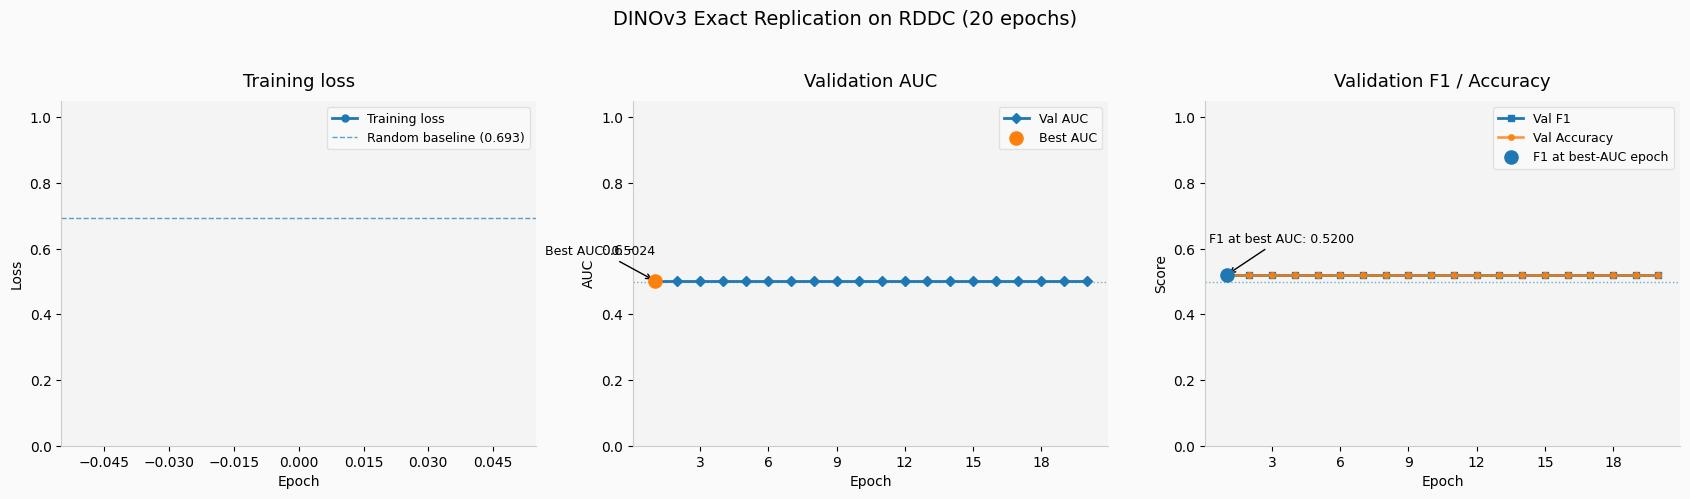

In [ ]:
%matplotlib inline
import os, json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import Image, display

LOG_PATH = "/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_exact_train/log.txt"

def parse_dinov3_linear_json_log(path):
    all_entries = []

    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "epoch" in entry:
                all_entries.append(entry)

    if not all_entries:
        raise RuntimeError(f"No JSON epoch entries found in {path}")

    # Use only the last run if the log contains restarted runs
    runs = []
    current_run = []
    prev_epoch = -1

    for entry in all_entries:
        ep = int(entry.get("epoch", 0))

        if ep <= prev_epoch and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(entry)
        prev_epoch = ep

    if current_run:
        runs.append(current_run)

    entries = runs[-1]

    # Display epochs as 1-based
    epochs = [int(e["epoch"]) + 1 for e in entries]

    train_losses = [
        float(e.get("train_loss", np.nan))
        for e in entries
    ]

    val_aucs = [
        float(e.get("val_auc", np.nan))
        for e in entries
    ]

    val_f1s = [
        float(e.get("val_f1", np.nan))
        for e in entries
    ]

    val_accs = [
        float(e.get("val_acc", np.nan))
        for e in entries
    ]

    val_aps = [
        float(e.get("val_ap", np.nan))
        for e in entries
    ]

    return epochs, train_losses, val_aucs, val_f1s, val_accs, val_aps, len(runs)


def plot_training(path):
    epochs, losses, aucs, f1s, accs, aps, n_runs = parse_dinov3_linear_json_log(path)

    aucs_np = np.array(aucs, dtype=float)
    best_auc_idx = int(np.nanargmax(aucs_np))

    best_auc_epoch = epochs[best_auc_idx]
    best_auc = aucs[best_auc_idx]
    f1_at_best_auc = f1s[best_auc_idx]
    acc_at_best_auc = accs[best_auc_idx]

    print(f"Best AUC: {best_auc:.4f} at epoch {best_auc_epoch}")
    print(f"F1 at best AUC epoch: {f1_at_best_auc:.4f} at epoch {best_auc_epoch}")
    print(f"Accuracy at best AUC epoch: {acc_at_best_auc:.4f} at epoch {best_auc_epoch}")
    print(f"Detected runs in log: {n_runs}")

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    fig.patch.set_facecolor("#FAFAFA")

    for ax in axes:
        ax.set_facecolor("#F4F4F4")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # 1. Training loss
    ax = axes[0]
    ax.plot(
        epochs,
        losses,
        marker="o",
        linewidth=2,
        markersize=5,
        label="Training loss",
    )
    ax.axhline(
        0.693,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="Random baseline (0.693)",
    )
    ax.set_ylim(0, 1.05)
    ax.set_title("Training loss", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9, framealpha=0.5)

    # 2. Validation AUC
    ax = axes[1]
    ax.plot(
        epochs,
        aucs,
        marker="D",
        linewidth=2,
        markersize=5,
        label="Val AUC",
    )
    ax.fill_between(epochs, 0.5, aucs, alpha=0.15)

    ax.scatter(best_auc_epoch, best_auc, s=90, zorder=5, label="Best AUC")
    ax.annotate(
        f"Best AUC: {best_auc:.4f}",
        xy=(best_auc_epoch, best_auc),
        xytext=(best_auc_epoch - max(epochs) * 0.12, best_auc + 0.08),
        fontsize=9,
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1),
    )
    ax.axhline(0.5, linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_title("Validation AUC", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("AUC")
    ax.legend(fontsize=9, framealpha=0.5)

    # 3. Validation F1 and Accuracy
    ax = axes[2]
    ax.plot(
        epochs,
        f1s,
        marker="s",
        linewidth=2,
        markersize=5,
        label="Val F1",
    )
    ax.plot(
        epochs,
        accs,
        marker="o",
        linewidth=1.8,
        markersize=4,
        alpha=0.85,
        label="Val Accuracy",
    )

    ax.scatter(
        best_auc_epoch,
        f1_at_best_auc,
        s=90,
        zorder=5,
        label="F1 at best-AUC epoch",
    )
    ax.annotate(
        f"F1 at best AUC: {f1_at_best_auc:.4f}",
        xy=(best_auc_epoch, f1_at_best_auc),
        xytext=(best_auc_epoch + max(epochs) * 0.12, f1_at_best_auc + 0.10),
        fontsize=9,
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1),
    )
    ax.axhline(0.5, linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_title("Validation F1 / Accuracy", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.legend(fontsize=9, framealpha=0.5)

    plt.suptitle(
        f"DINOv3 repl Replication on RDDC ({len(epochs)} epochs)",
        fontsize=14,
        y=1.03,
    )
    plt.tight_layout()

    out_path = "dinov3_exact_training_curves.jpg"
    plt.savefig(out_path, dpi=100, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)

    display(Image(out_path))


plot_training(LOG_PATH)

In [ ]:
import shutil
from pathlib import Path

CKPT_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_exact_test")

if CKPT_DIR.exists():
    shutil.rmtree(CKPT_DIR)
    print("🧹 Old checkpoints deleted")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Fresh checkpoint directory created:", CKPT_DIR)

✅ Fresh checkpoint directory created: /content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_exact_test


In [ ]:
BEST_PATH = "/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_exact_train/best.pth"
TEST_OUTPUT_DIR = "/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_exact_test"
os.makedirs(TEST_OUTPUT_DIR, exist_ok=True)

checkpoint = torch.load(BEST_PATH, map_location=device, weights_only=False)

model = ShallowRealDINOv3MAC(
    model_name=MODEL_NAME,
    lora_r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    dropout=0.2,
    drop_path_rate=0.1,
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_metrics, test_probs, test_labels = evaluate(model, test_loader, device)

print("Best epoch:", checkpoint["epoch"])
print("Best val:", checkpoint["val_metrics"])
print("TEST:", test_metrics)

with open(os.path.join(TEST_OUTPUT_DIR, "log.txt"), "w") as f:
    f.write(json.dumps({
        "best_epoch": int(checkpoint["epoch"]),
        "test_auc": float(test_metrics["auc"]),
        "test_ap": float(test_metrics["ap"]),
        "test_f1": float(test_metrics["f1"]),
        "test_acc": float(test_metrics["acc"]),
    }) + "\n")

np.save(os.path.join(TEST_OUTPUT_DIR, "test_probs.npy"), test_probs)
np.save(os.path.join(TEST_OUTPUT_DIR, "test_labels.npy"), test_labels)

NameError: name 'MODEL_NAME' is not defined

In [ ]:
import os, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
)

MODEL_NAME = "DINOv3 Exact"
TEST_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_exact_test")
TEST_DIR.mkdir(parents=True, exist_ok=True)

PROBS_PATH = TEST_DIR / "test_probs.npy"
LABELS_PATH = TEST_DIR / "test_labels.npy"

test_probs = np.load(PROBS_PATH).reshape(-1)
test_labels = np.load(LABELS_PATH).astype(int).reshape(-1)

threshold = 0.5
test_preds = (test_probs >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(test_labels, test_preds, labels=[0, 1]).ravel()

precision = precision_score(test_labels, test_preds, zero_division=0)
recall = recall_score(test_labels, test_preds, zero_division=0)
f1 = f1_score(test_labels, test_preds, zero_division=0)
accuracy = accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)

metric_summary = {
    "model": MODEL_NAME,
    "artifact_type": "metric_summary_from_inference",
    "threshold": threshold,
    "confusion_matrix": {
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
    },
    "metrics": {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(accuracy),
        "auc": float(auc),
        "ap": float(ap),
    },
}

with open(TEST_DIR / "metric_summary.json", "w") as f:
    json.dump(metric_summary, f, indent=2)

with open(TEST_DIR / "mac_test_summary.json", "w") as f:
    json.dump(metric_summary, f, indent=2)

np.save(TEST_DIR / "test_preds.npy", test_preds)

total = tp + tn + fp + fn
correct = tp + tn
wrong = fp + fn

print(f"Test F1  : {f1:.4f}")
print(f"Test AUC : {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Result   : {correct}/{total}")

print(f"{'═'*44}")
print(f"  Confusion Matrix Results (Dino exact)")
print(f"{'═'*44}")
print(f"  TP (fake correctly detected) : {tp}")
print(f"  TN (real correctly detected) : {tn}")
print(f"  FP (real wrongly called fake): {fp}")
print(f"  FN (fake wrongly called real): {fn}")
print(f"{'-'*44}")

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[tn, fp], [fn, tp]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])
ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)
ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"{MODEL_NAME} public test · Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()

fig_path = TEST_DIR / "shallowreal_vitl_exact_test_confusion_matrix.jpg"
plt.savefig(fig_path, dpi=80, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

display(IPyImage(filename=str(fig_path)))

In [ ]:
# ── Badly / Well Detected — DINOv3 MAC PublicTest ──

%matplotlib inline

import os
import json
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image as IPyImage, display

# ── Paths ─────────────────────────────────────────────────────────────────────
TEST_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/shallowreal_vitl_exact_test")
TEST_JSON = "/content/DiffusionForensics_Recons/test.json"

PROBS_PATH = TEST_DIR / "test_probs.npy"
LABELS_PATH = TEST_DIR / "test_labels.npy"

# ── Load test outputs ─────────────────────────────────────────────────────────
test_probs = np.load(PROBS_PATH).reshape(-1)
test_labels = np.load(LABELS_PATH).astype(int).reshape(-1)

with open(TEST_JSON, "r") as f:
    test_items = json.load(f)

assert len(test_items) == len(test_probs) == len(test_labels), \
    f"Mismatch: items={len(test_items)}, probs={len(test_probs)}, labels={len(test_labels)}"

# ── Build result records ──────────────────────────────────────────────────────
threshold = 0.5
results = []

for item, score, true_label in zip(test_items, test_probs, test_labels):
    pred = int(score >= threshold)
    results.append({
        "path": item["path"],
        "true_label": int(true_label),
        "pred": pred,
        "score": float(score),
        "confidence": float(score),
        "correct": pred == int(true_label),
    })

total = len(results)
n_correct = sum(r["correct"] for r in results)
accuracy = 100 * n_correct / total

well  = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

well_sorted  = sorted(well,  key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

well_sample  = well_sorted[:50]
badly_sample = badly_sorted[:50]

n_real = sum(r["true_label"] == 0 for r in results)
n_fake = sum(r["true_label"] == 1 for r in results)

tp = sum((r["true_label"] == 1 and r["pred"] == 1) for r in results)
tn = sum((r["true_label"] == 0 and r["pred"] == 0) for r in results)
fp = sum((r["true_label"] == 0 and r["pred"] == 1) for r in results)
fn = sum((r["true_label"] == 1 and r["pred"] == 0) for r in results)

real_acc = 100 * tn / max(1, n_real)
fake_acc = 100 * tp / max(1, n_fake)
precision_fake = tp / max(1, tp + fp)
recall_fake = tp / max(1, tp + fn)
f1_fake = 2 * precision_fake * recall_fake / max(1e-12, precision_fake + recall_fake)

print(f"PublicTest: {n_correct}/{total} correct ({accuracy:.1f}% accuracy)")
print(f"REAL images: {n_real}  |  FAKE images: {n_fake}")
print(f"Well detected: {len(well)}  |  Badly detected: {len(badly)}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"\nREAL accuracy: {real_acc:.2f}%")
print(f"FAKE accuracy: {fake_acc:.2f}%")
print(f"FAKE precision: {precision_fake:.4f}")
print(f"FAKE recall: {recall_fake:.4f}")
print(f"FAKE F1: {f1_fake:.4f}")

# ── Save per-image inference JSON inside mac_test ─────────────────────────────
RESULTS_JSON = TEST_DIR / "shallowreal_vitl_exact_test_inference_results.json"

with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved per-image results to:", RESULTS_JSON)

# ── Helpers ───────────────────────────────────────────────────────────────────
def label_str(l):
    return "REAL" if l == 0 else "FAKE"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop(((w - side) // 2, (h - side) // 2,
                    (w + side) // 2, (h + side) // 2))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename):
    n = len(samples)
    cols = 10
    rows = max(1, (n + cols - 1) // cols)

    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.5))
    fig.patch.set_facecolor('#1a1a1a')

    if rows == 1:
        axes = [axes]

    for idx, ax in enumerate([a for row in axes for a in row]):
        if idx >= n:
            ax.axis('off')
            continue

        r = samples[idx]
        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'error', ha='center', va='center',
                    color='white', fontsize=7, transform=ax.transAxes)

        true_color = '#2ecc71' if r["true_label"] == 0 else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        fname = os.path.basename(r["path"])
        ax.set_title(
            f"{fname}\nTrue: {label_str(r['true_label'])} -> Pred: {label_str(r['pred'])}\n"
            f"score: {r['confidence']:.3f}",
            fontsize=8,
            color='white',
            pad=9,
        )

    real_p = mpatches.Patch(color='#2ecc71', label='True label: REAL')
    fake_p = mpatches.Patch(color='#e74c3c', label='True label: FAKE')
    fig.legend(
        handles=[real_p, fake_p],
        loc='lower center',
        ncol=2,
        fontsize=10,
        framealpha=0.3,
        facecolor='#333',
        labelcolor='white',
        bbox_to_anchor=(0.5, 0.005),
    )

    fig.suptitle(title, fontsize=14, color='white', fontweight='medium')
    plt.subplots_adjust(hspace=0.7, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(filename, dpi=90, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    display(IPyImage(filename=str(filename)))

# ── Plots ─────────────────────────────────────────────────────────────────────
well_fig = TEST_DIR / "shallowreal_vitl_repl_well_detected_test.jpg"
badly_fig = TEST_DIR / "shallowreal_vitl_repl_badly_detected_test.jpg"

make_grid(
    well_sample,
    title='DINOv3 exact · 50 most confidently CORRECT predictions\nBorder = true label',
    filename=well_fig,
)

make_grid(
    badly_sample,
    title='DINOv3 exact · 50 most confidently WRONG predictions\nBorder = true label',
    filename=badly_fig,
)

print("\nSaved figures:")
print(" -", well_fig)
print(" -", badly_fig)

In [ ]:
import nbformat
NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime_Working/Code Notebooks/dinov3_exact_replication.ipynb"

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, NOTEBOOK_PATH)

In [ ]:
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime_Working/Code Notebooks/dinov3_exact_replication.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime_Working/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")